Raw shape: (145460, 23)
Shape after cleaning: (142193, 23)
Remaining nulls: 0
Rows removed by Rainfall outlier filter: 28545
Shape after outlier removal: (113648, 27)
RainTomorrow
No     95420
Yes    18228
Name: count, dtype: int64
Class balance: 16.0% Rain
Categorical columns to encode: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month', 'Season']
Location            int64
MinTemp           float64
MaxTemp           float64
Rainfall          float64
Evaporation       float64
Sunshine          float64
WindGustDir         int64
WindGustSpeed     float64
WindDir9am          int64
WindDir3pm          int64
WindSpeed9am      float64
WindSpeed3pm      float64
Humidity9am       float64
Humidity3pm       float64
Pressure9am       float64
Pressure3pm       float64
Cloud9am          float64
Cloud3pm          float64
Temp9am           float64
Temp3pm           float64
RainToday           int64
Month               int64
Season              int64
TempRange         float64

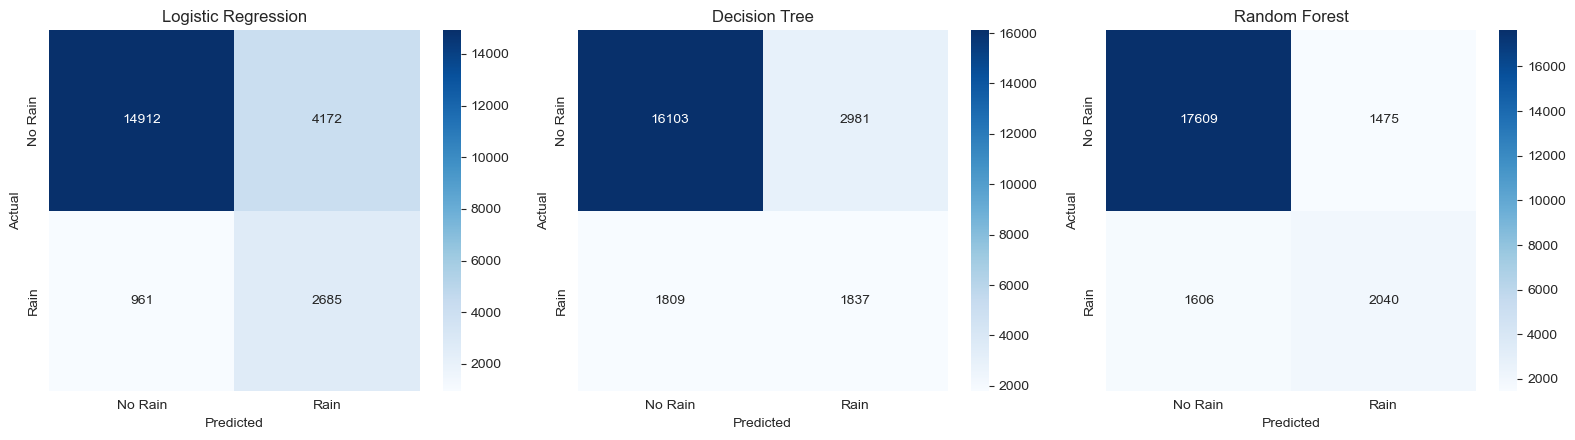

Logistic Regression: F1 per fold = [0.5137 0.5152 0.5073 0.5121 0.5255] | Mean = 0.5148 | Std = 0.0060
Decision Tree: F1 per fold = [0.4276 0.4377 0.4201 0.4303 0.4211] | Mean = 0.4274 | Std = 0.0065
Random Forest: F1 per fold = [0.5703 0.5731 0.5579 0.5615 0.559 ] | Mean = 0.5643 | Std = 0.0062
                     Mean F1 (CV)  Std F1 (CV)
Logistic Regression        0.5148       0.0060
Decision Tree              0.4274       0.0065
Random Forest              0.5643       0.0062
                     Accuracy  Precision  Recall  F1-Score  Mean F1 (CV)
Model                                                                   
Random Forest          0.8645     0.5804  0.5595    0.5698        0.5643
Logistic Regression    0.7742     0.3916  0.7364    0.5113        0.5148
Decision Tree          0.7893     0.3813  0.5038    0.4341        0.4274


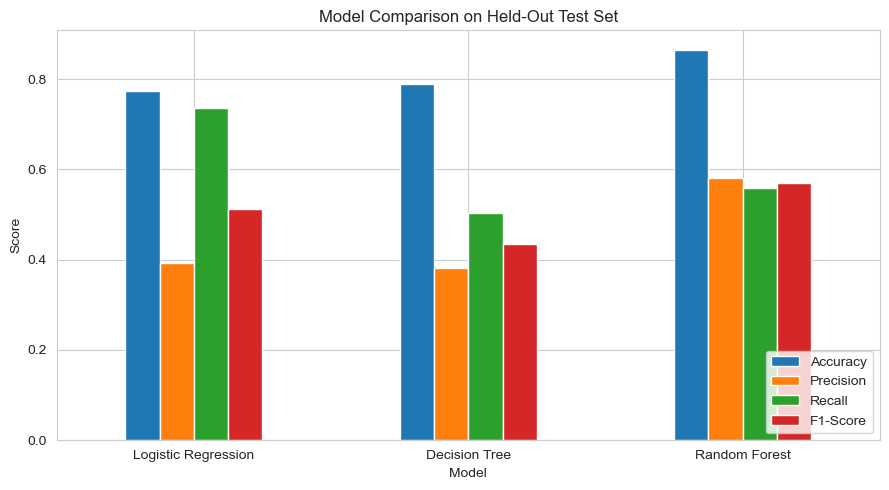


🏆 BEST MODEL: Random Forest
   F1-Score (Test):  0.5698
   Accuracy:         0.8645
   Precision (Rain): 0.5804
   Recall (Rain):    0.5595
   CV F1 Mean:       0.5643

✅ PHASE 3: MODEL TRAINING & EVALUATION COMPLETE


In [1]:
# ==============================================================================
# PHASE 3: MODEL TRAINING & EVALUATION — WEATHER PREDICTION PROJECT
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


# ------------------------------------------------------------------------------
# STEP 1: LOAD DATA & REPRODUCE PHASE 2 FEATURE ENGINEERING
# Reloading the raw CSV and reproducing Phase 2's cleaning + engineered features
# so this notebook can run standalone.
# ------------------------------------------------------------------------------
df = pd.read_csv('../weatherAUS.csv')
print(f"Raw shape: {df.shape}")

df = df.drop_duplicates()
df.dropna(subset=['RainTomorrow'], inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

# --- Date & time extraction — same as Phase 2 ---
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Month'] = df['Date'].dt.month_name()

def month_to_season(month_num):
    if month_num in [12, 1, 2]:
        return 'Summer'
    elif month_num in [3, 4, 5]:
        return 'Autumn'
    elif month_num in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df['Season'] = df['Date'].dt.month.apply(month_to_season)

# --- Derived numeric features — same as Phase 2 ---
df['TempRange'] = df['MaxTemp'] - df['MinTemp']
df['HumidityChange'] = df['Humidity3pm'] - df['Humidity9am']
df['PressureChange'] = df['Pressure3pm'] - df['Pressure9am']

# Date's signal is now captured in Month/Season — drop the raw column
df.drop(columns=['Date'], inplace=True)

# --- Outlier removal on Rainfall (IQR) — carried over from Phase 1 ---
Q1 = df['Rainfall'].quantile(0.25)
Q3 = df['Rainfall'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = df.shape[0]
df = df[(df['Rainfall'] >= lower) & (df['Rainfall'] <= upper)]
print(f"Rows removed by Rainfall outlier filter: {before - df.shape[0]}")
print(f"Shape after outlier removal: {df.shape}")

df['RainTomorrow_num'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})
print(df['RainTomorrow'].value_counts())
print(f"Class balance: {df['RainTomorrow_num'].mean()*100:.1f}% Rain")


# ------------------------------------------------------------------------------
# STEP 2: ENCODE CATEGORICAL FEATURES
# Label Encoding, consistent with Phase 1/Phase 2. Appropriate here since all
# three models are either tree-based or a baseline.
# ------------------------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

df_model = df.drop(columns=['RainTomorrow']).rename(columns={'RainTomorrow_num': 'RainTomorrow'})

categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print(df_model.dtypes)


# ------------------------------------------------------------------------------
# STEP 3: TRAIN/TEST SPLIT — BEFORE ANY FITTING
# The split happens first, on raw (unscaled, unresampled) data, stratified
# since the target is imbalanced (~84/16). Nothing downstream sees the test
# set during fitting.
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['RainTomorrow'])
y = df_model['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}  | Rain %: {y_train.mean()*100:.1f}%")
print(f"Test shape:  {X_test.shape}  | Rain %: {y_test.mean()*100:.1f}%")


# ------------------------------------------------------------------------------
# STEP 4: SCALE FEATURES — FIT ON TRAIN ONLY
# MinMaxScaler is fit on the training set only, then used to transform both
# train and test. The test set never influences the scaler's parameters.
# ------------------------------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaling complete. Train range check:")
print(X_train_scaled.describe().loc[['min', 'max']].T.head())


# ------------------------------------------------------------------------------
# STEP 5: SMOTE-TOMEK — TRAINING SET ONLY
# Applied only to training data. Test set stays at its natural ~84/16
# imbalance so evaluation reflects real-world performance.
# ------------------------------------------------------------------------------
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train_scaled, y_train)

print("Before resampling:", y_train.value_counts().to_dict())
print("After resampling: ", y_train_res.value_counts().to_dict())


# ------------------------------------------------------------------------------
# STEP 6: MODEL TRAINING
# Logistic Regression (baseline), Decision Tree, Random Forest (primary) —
# per the task sheet's classification track.
# ------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    print(f"{name} trained.")


# ------------------------------------------------------------------------------
# STEP 7: EVALUATION ON THE UNTOUCHED TEST SET
# Accuracy, Precision, Recall, F1-Score, Confusion Matrix.
# ------------------------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

    print(f"\n==================== {name} ====================")
    print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

# Confusion matrices, side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()
# Interpretation: For a weather model, a false negative (predicting "No Rain"
# when it actually rains) is the costlier mistake. Recall on the "Rain" class
# is watched closely alongside Accuracy, not treated as secondary to it.


# ------------------------------------------------------------------------------
# STEP 8: CROSS-VALIDATION (STRATIFIED K-FOLD)
# StratifiedKFold used over plain K-Fold since the target is imbalanced.
# SMOTE-Tomek is refit fresh inside each fold via an imblearn pipeline, so no
# fold's resampling leaks information across folds.
# ------------------------------------------------------------------------------
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model_cls in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42, n_jobs=-1)),
]:
    pipe = ImbPipeline([
        ('scaler', MinMaxScaler()),
        ('smote_tomek', SMOTETomek(random_state=42)),
        ('model', model_cls),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: F1 per fold = {np.round(scores, 4)} | Mean = {scores.mean():.4f} | Std = {scores.std():.4f}")

cv_summary = pd.DataFrame({
    name: {"Mean F1 (CV)": scores.mean(), "Std F1 (CV)": scores.std()}
    for name, scores in cv_results.items()
}).T
print(cv_summary.round(4))


# ------------------------------------------------------------------------------
# STEP 9: MODEL COMPARISON & FINAL SELECTION
# ------------------------------------------------------------------------------
comparison = results_df.copy()
comparison['Mean F1 (CV)'] = [cv_results[name].mean() for name in comparison.index]
print(comparison.round(4).sort_values('F1-Score', ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax)
plt.title('Model Comparison on Held-Out Test Set')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# MODEL COMPARISON & JUSTIFICATION
# Fill this in with your actual printed numbers before submitting:
#
# - Logistic Regression: baseline, expected weakest on Recall/F1 (linear model
#   struggles with non-linear weather thresholds)
# - Decision Tree: captures non-linear interactions, watch for overfitting
#   (gap between train performance and CV F1)
# - Random Forest: primary/ensemble model, averages many trees to reduce
#   overfitting vs a single tree
#
# Final model selection should be based on Recall + F1-Score on the Rain
# class, NOT raw Accuracy — the test set stays ~84/16, so a model that always
# predicts "No Rain" would still show ~84% accuracy while being useless.
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# FINAL MODEL SELECTION
# ------------------------------------------------------------------------------
best_model = comparison.sort_values('F1-Score', ascending=False).index[0]

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model}")
print("="*60)
print(f"   F1-Score (Test):  {comparison.loc[best_model, 'F1-Score']:.4f}")
print(f"   Accuracy:         {comparison.loc[best_model, 'Accuracy']:.4f}")
print(f"   Precision (Rain): {comparison.loc[best_model, 'Precision']:.4f}")
print(f"   Recall (Rain):    {comparison.loc[best_model, 'Recall']:.4f}")
print(f"   CV F1 Mean:       {comparison.loc[best_model, 'Mean F1 (CV)']:.4f}")
print("="*60)

print("\n✅ PHASE 3: MODEL TRAINING & EVALUATION COMPLETE")